# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Afia Nyarkoa Otieku-Boadu
**Student ID:** 55002028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [79]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

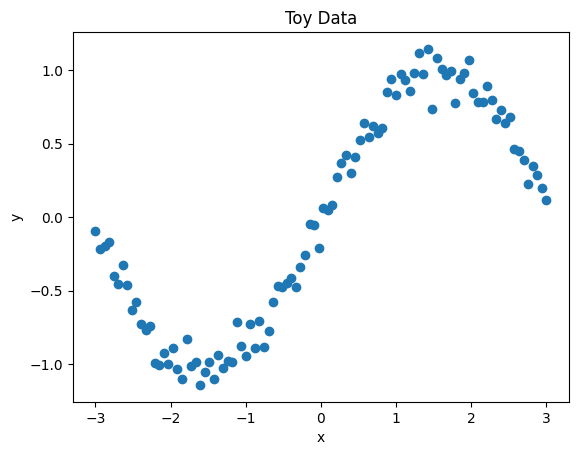

[np.float64(0.5319618242000635), np.float64(0.4920286153564831), np.float64(0.45683445786818355), np.float64(0.4258169383733008), np.float64(0.3984803890397071), np.float64(0.3743879663916405), np.float64(0.3531546701996664), np.float64(0.3344411908697882), np.float64(0.3179484870076631), np.float64(0.30341300650270436), np.float64(0.29060247476086953), np.float64(0.27931218277845704), np.float64(0.2693617157371307), np.float64(0.26059206984030125), np.float64(0.2528631113154318), np.float64(0.24605133697493933), np.float64(0.24004790054753616), np.float64(0.23475687323909378), np.float64(0.230093710725306), np.float64(0.2259839020773851), np.float64(0.2223617790294738), np.float64(0.21916946655885292), np.float64(0.21635595800832952), np.float64(0.21387629997047736), np.float64(0.21169087390749358), np.float64(0.2097647630263538), np.float64(0.2080671942914006), np.float64(0.20657104665726034), np.float64(0.20525241766324331), np.float64(0.20409024146304655), np.float64(0.203065952185

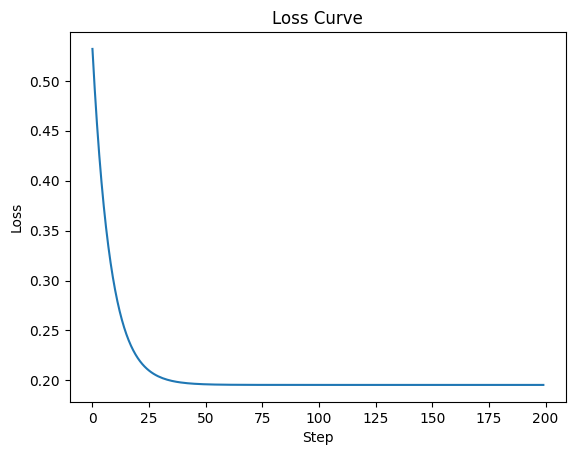

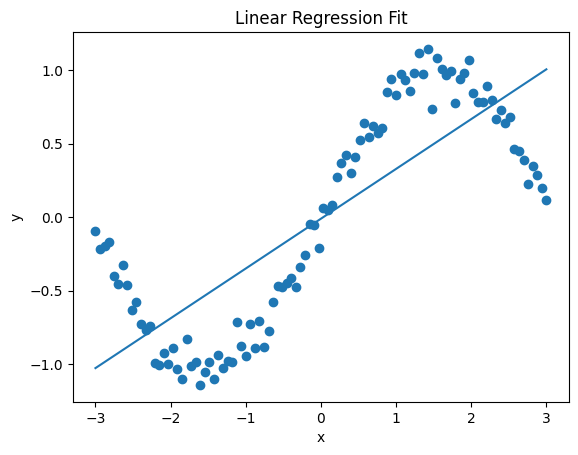

In [80]:
# Generating the toy data and plotting it
x = np.linspace(-3, 3, 100); y = np.sin(x) + np.random.normal(0, 0.1, 100)
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data")

plt.show()


# Initialising w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.01

# Implementing ONE gradient-descent step by hand, then looping it for ~200 steps:
y_hat = w * x + b
loss  = np.mean((y_hat - y) ** 2)               # MSE
dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw
db    = np.mean(2 * (y_hat - y))                # dLoss/db
w    -= lr * dw
b    -= lr * db

losses = []

for i in range(200):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)               # MSE
  dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw
  db    = np.mean(2 * (y_hat - y))                # dLoss/db
  w    -= lr * dw
  b    -= lr * db

  #  Recording the loss at every step.
  losses.append(loss)

print(losses)

# Plotting the loss curve over the 200 steps, and the data with the fitted line on top.

plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 1. It matches the code 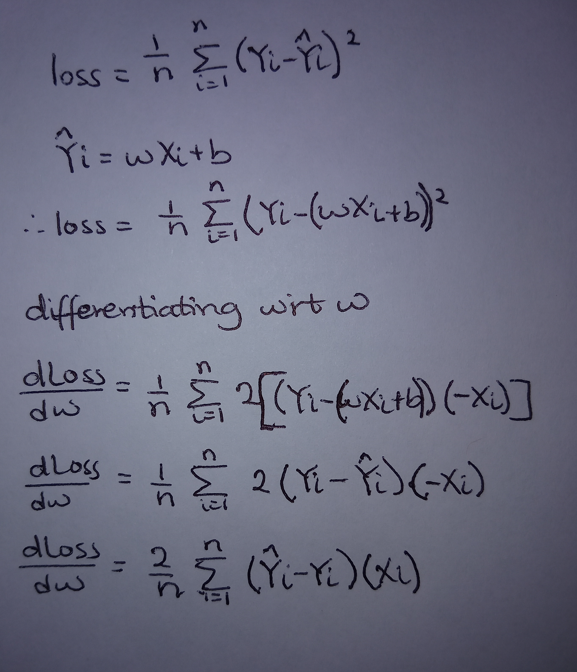
2. Underfitting because the model is too simple to learn the true relationship of the data. A single neuron can only compute a linear function and since a sine wave is non-linear, no matter how long it is trained it can never fit the wave without an activation function.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

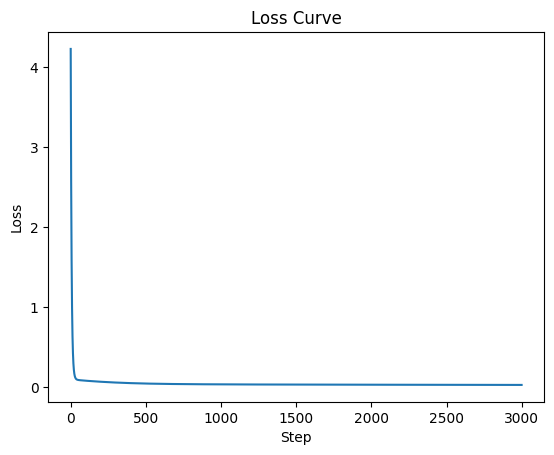

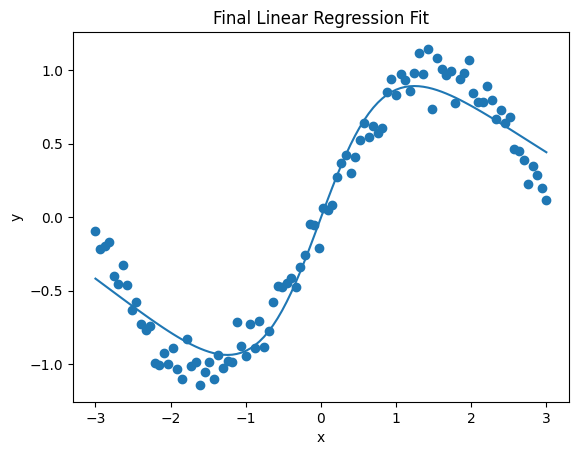

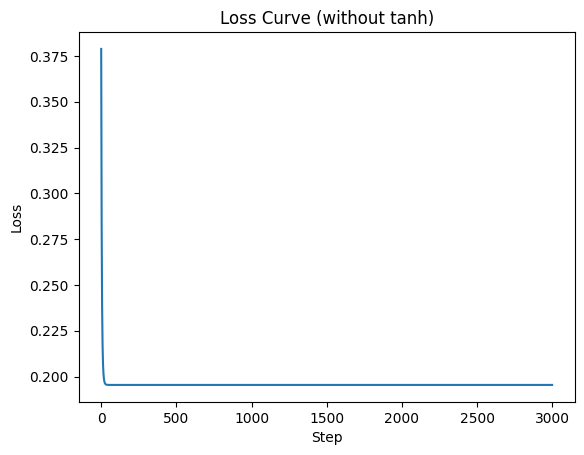

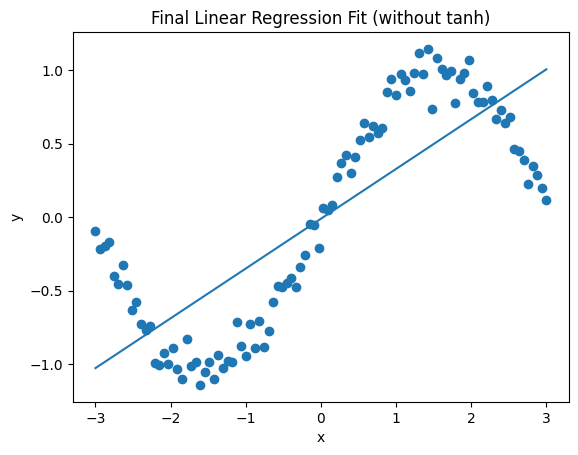

In [81]:
# Initialising parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

# Forward pass:
z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# Backward pass:
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# Updating all parameters with learning rate lr, looping for ~3000 steps, and recording the loss.

losses2 = []

for i in range(3000):
  z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
  h  = np.tanh(z1)        # activation
  y_hat = h @ W2 + b2     # output, shape (100, 1)
  loss  = np.mean((y_hat - y) ** 2)

  # Backward pass:
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
  dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

  W1 -= lr*dW1
  b1 -= lr*db1
  W2 -= lr*dW2
  b2 -= lr*db2

  losses2.append(loss)


# Plotting the loss curve AND the final fit over the data.

plt.plot(losses2)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Linear Regression Fit")

plt.show()

#   Re-running with the tanh REMOVED (h = z1).

W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

# Forward pass
z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = z1       # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# Backward pass:
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - z1 ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# Updating all parameters with learning rate lr, looping for ~3000 steps and recording the loss.

losses3 = []

for i in range(3000):
  z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
  h  = z1        # activation
  y_hat = h @ W2 + b2     # output, shape (100, 1)
  loss  = np.mean((y_hat - y) ** 2)

  # Backward pass:
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh      # derivative of h
  dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

  W1 -= lr*dW1
  b1 -= lr*db1
  W2 -= lr*dW2
  b2 -= lr*db2

  losses3.append(loss)


# Plotting the loss curve AND the final fit over the data.

plt.plot(losses3)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve (without tanh)")

plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Linear Regression Fit (without tanh)")

plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 1. Linear layers can only perform linear computations. Multiple linear computations can always be represented as one linear computation and as such will always produce a linear output. This same reasoning explains why multiple linear layers collapse into one linear layer.
2. The hidden layer's neurons extract the features and pass it through the linear and activation functions to get the different parts of the curve.
3. Backpropagation refers to determining the amount each weight contributed to the final loss to readjust them to reduce the loss.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

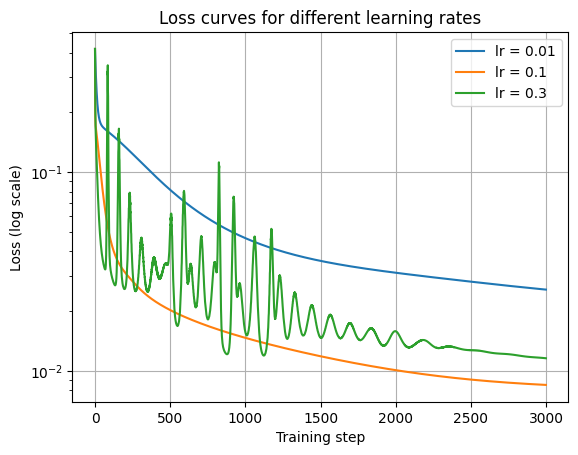

In [82]:
# Wrapping Part 1.2 in a training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps = 3000):
  W1 = W1_initial.copy()
  b1 = b1_initial.copy()
  W2 = W2_initial.copy()
  b2 = b2_initial.copy()

  losses = []

  for i in range(steps):
    # Forward pass
    z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h  = np.tanh(z1)        # activation
    y_hat = h @ W2 + b2     # output, shape (100, 1)
    loss  = np.mean((y_hat - y) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

    losses.append(loss)

  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

W1_initial = np.random.randn(1,8) * 0.5
b1_initial = np.random.randn(8) * 0.5
W2_initial = np.random.randn(8,1) * 0.5
b2_initial = np.random.randn(1) * 0.5

losses_a = train_toy(0.01)
losses_b = train_toy(0.1)
losses_c = train_toy(0.3)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.plot(losses_a, label="lr = 0.01")
plt.plot(losses_b, label="lr = 0.1")
plt.plot(losses_c, label="lr = 0.3")

plt.yscale("log")

plt.xlabel("Training step")
plt.ylabel("Loss (log scale)")
plt.title("Loss curves for different learning rates")

plt.legend()
plt.grid(True)

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** The learning rate of 0.01 shows a gradual descen. This is also the same for the learning rate of 0.1 which just shows a slightly steeper initial descent but later continues to grow at a similar rate to that of 0.01. However, with the learning rate of 0.3, the line begins to oscillate. This is because a too-large learning rate results in the model taking large steps during gradient descent, meaning it may easily miss the optimal solution, resulting in the loss explode or oscillation.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [83]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

ordinal_cols = ["CAEC", "CALC"]
encoder = OrdinalEncoder(
    categories=[
        ["no", "Sometimes", "Frequently", "Always"],
        ["no", "Sometimes", "Frequently", "Always"]
    ]
)
obesity[ordinal_cols] = encoder.fit_transform(obesity[ordinal_cols])

nominal_cols = ["Gender", "MTRANS"]
obesity = pd.get_dummies(obesity, columns=nominal_cols, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(obesity["NObeyesdad"])

X = obesity.drop(columns=["NObeyesdad"])
X = X.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train shape: (1266, 19)
Validation shape: (422, 19)
Test shape: (423, 19)


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 1. CrossEntropyLoss uses integers to represent the different classes so that it can compare the model's output directly with the class index which is more efficient than using one-hot vectors.
2. Random forests focus more on features than on their values. Since neural networks use gradient decent to update their weights, the size of the gradient is affected by the size of the value. In order to prevent false weight updates, the features are scaled to similar sizes so that no one feature is given much priority over another.
3. It shuffles the order of the data, preventing the model from memorising patterns due to the order it is represented which may lead to overfitting.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [84]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32, 16), n_classes=7, dropout=0.0):
        super().__init__()
        self.layers = nn.ModuleList()
        prev_dim = input_dim

        for h_size in hidden_sizes:
            self.layers.append(nn.Linear(prev_dim, h_size))
            prev_dim = h_size

        self.classifier = nn.Linear(prev_dim, n_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        if len(self.layers) > 0:
            self.fc1 = self.layers[0]

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
            x = self.relu(x)
            if self.dropout.p > 0:
                x = self.dropout(x)
        out = self.classifier(x)
        return out

input_dim = X_train_tensor.shape[1]
model = FeedForwardNet(input_dim)
model = model.to(DEVICE)
print(model)

sum_param = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", sum_param)

sum_layer1 = model.fc1.weight.numel() + model.fc1.bias.numel()
print("First layer matches manual calculation:", sum_layer1 == (input_dim * 64 + 64))

FeedForwardNet(
  (layers): ModuleList(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): Linear(in_features=32, out_features=16, bias=True)
  )
  (classifier): Linear(in_features=16, out_features=7, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=19, out_features=64, bias=True)
)
Total parameters: 4007
First layer matches manual calculation: True


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 1. layer 1 = 19*64 + 64 = 1280
layer 2 = 64*32 + 32 = 2080
layer 3 = 32*16 + 16 = 528
output layer = 16*7 + 7 = 119
Total = 4007 which matches PyTorch
2. ReLU does not cause much change as it only discards negative values, leaving positive values unchanged, unlike tanh which has to handle the vanishing gradient problem for positive values.
3. If the ReLUs were removed, the model will be full of linear functions which can only learn linear relationships. This will mean that the model would compute only linear computations to produce a linear output.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.8308 | Val Loss: 1.8299 | Train Acc: 0.3412 | Val Acc: 0.3507
Epoch 02/50 | Train Loss: 1.4666 | Val Loss: 1.4801 | Train Acc: 0.5229 | Val Acc: 0.5403
Epoch 03/50 | Train Loss: 1.0691 | Val Loss: 1.0782 | Train Acc: 0.5948 | Val Acc: 0.5995
Epoch 04/50 | Train Loss: 0.8054 | Val Loss: 0.8225 | Train Acc: 0.7062 | Val Acc: 0.7156
Epoch 05/50 | Train Loss: 0.6359 | Val Loss: 0.6827 | Train Acc: 0.7986 | Val Acc: 0.7701
Epoch 06/50 | Train Loss: 0.5138 | Val Loss: 0.5733 | Train Acc: 0.8325 | Val Acc: 0.8246
Epoch 07/50 | Train Loss: 0.4250 | Val Loss: 0.4899 | Train Acc: 0.8807 | Val Acc: 0.8412
Epoch 08/50 | Train Loss: 0.3558 | Val Loss: 0.4295 | Train Acc: 0.8973 | Val Acc: 0.8673
Epoch 09/50 | Train Loss: 0.3034 | Val Loss: 0.3796 | Train Acc: 0.9147 | Val Acc: 0.8720
Epoch 10/50 | Train Loss: 0.2612 | Val Loss: 0.3468 | Train Acc: 0.9336 | Val Acc: 0.8886
Epoch 11/50 | Train Loss: 0.2186 | Val Loss: 0.3080 | Train Acc: 0.9447 | Val Acc: 0.8886
Epoch 12/5

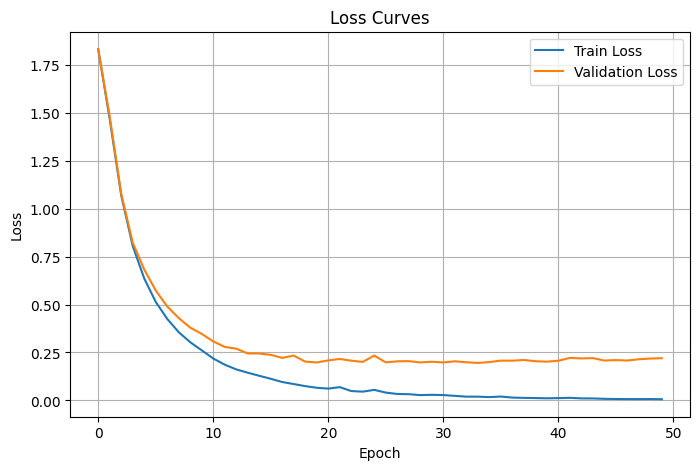

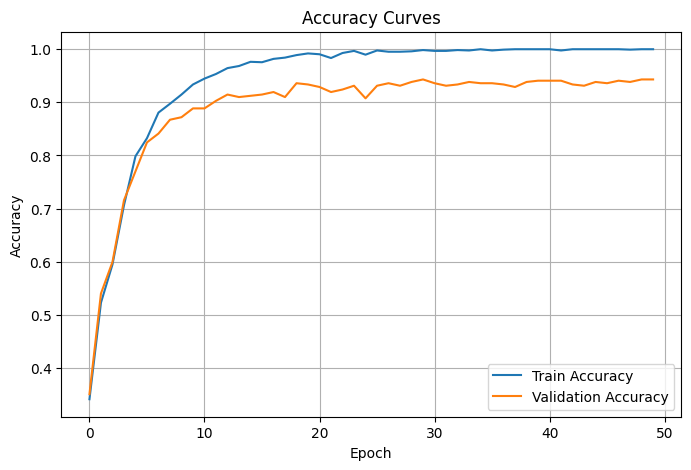

In [85]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []
train_accuracy = []
val_accuracy = []

highest_val_accuracy = 0.0

for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()

    model.eval()

    train_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            train_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == yb).sum().item()
            total += yb.size(0)
    train_loss /= len(train_loader)
    train_acc = correct / total

    val_loss = 0.0
    correct_v = 0
    total_v = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)
            correct_v += (predictions == yb).sum().item()
            total_v += yb.size(0)
    val_loss /= len(val_loader)
    val_acc = correct_v / total_v

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracy.append(train_acc)
    val_accuracy.append(val_acc)

    print(f"Epoch {epoch+1:02d}/50 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > highest_val_accuracy:
        highest_val_accuracy = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

# loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

# accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy, label="Train Accuracy")
plt.plot(val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 1. Forward pass: (NumPy)
z1 = x @ W1 + b1        
h  = np.tanh(z1)        
y_hat = h @ W2 + b2     

(PyTorch)
logits = model(xb.to(DEVICE))

Computing loss: (NumPy)
loss  = np.mean((y_hat - y) ** 2)

(PyTorch)
loss = criterion(logits, yb.to(DEVICE))

Backpropagation: (NumPy)
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)    
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
        
(PyTorch)        
loss.backward()

Update rule: (NumPy)
 W1 -= lr*dW1
 b1 -= lr*db1
 W2 -= lr*dW2
 b2 -= lr*db2

(PyTorch)
optimizer.step()

2. The model is slightly overfitted. Using epoch 50, it had a training accuracy of 1, but a validation accuracy of 0.9431. It also had a training loss of 0.0063 and a validation loss of 0.2203. This shows that the model is slightly overfitting.
3. Calling the function clears any stored gradients to prevent it from accumulating and giving wrong values.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

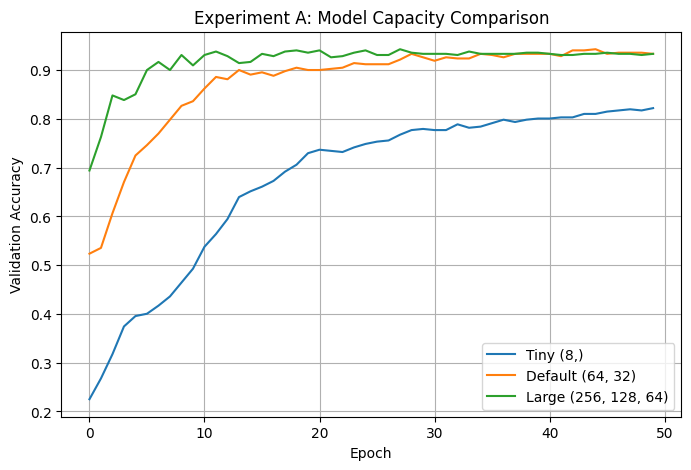

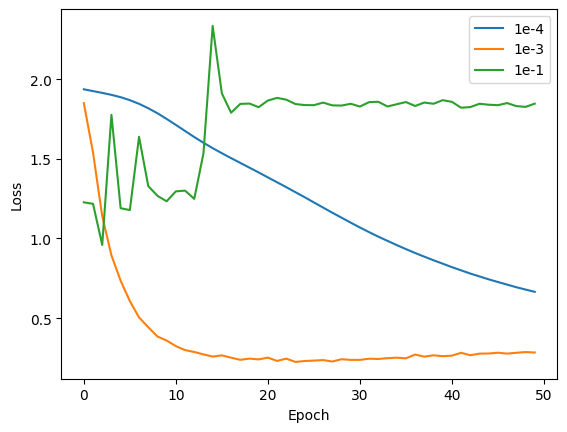

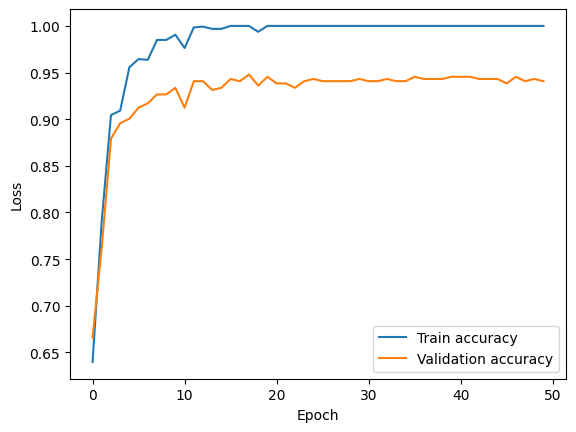

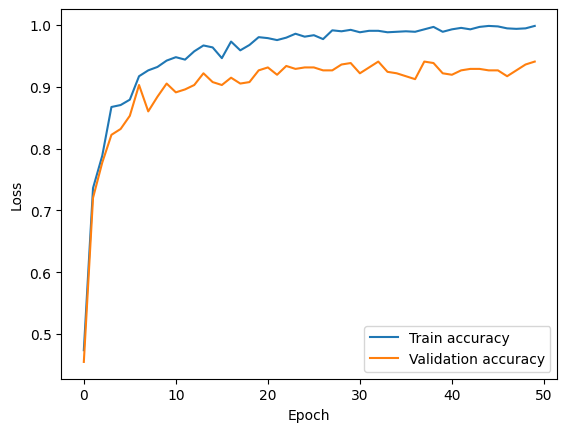

In [86]:
# Wrap your Part 2.3 loop in a function first:


def run_experiment(hidden_sizes=(64, 32, 16), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    input_dim = X_train_tensor.shape[1]
    model = FeedForwardNet(input_dim=input_dim, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    history = {
        "train_losses": [],
        "val_losses": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    highest_val_accuracy = 0.0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            loss.backward()
            optimizer.step()

        model.eval()

        # Train Metrics
        train_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                train_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)
        train_loss /= len(train_loader)
        train_acc = correct / total

        # Validation Metrics
        val_loss = 0.0
        correct_v = 0
        total_v = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct_v += (preds == yb).sum().item()
                total_v += yb.size(0)
        val_loss /= len(val_loader)
        val_acc = correct_v / total_v

        history["train_losses"].append(train_loss)
        history["val_losses"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        if val_acc > highest_val_accuracy:
            highest_val_accuracy = val_acc
            name = f"ffn_exp_{'_'.join(map(str, hidden_sizes))}_lr{lr}_do{dropout}.pt"
            torch.save(model.state_dict(), name)

    return history

#       ... returns history dict ...

tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128,64))

#   Plot the three validation-accuracy curves together.
plt.figure(figsize=(8, 5))
plt.plot(tiny["val_accuracy"], label="Tiny (8,)")
plt.plot(default["val_accuracy"], label="Default (64, 32)")
plt.plot(large["val_accuracy"], label="Large (256, 128, 64)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Model Capacity Comparison")
plt.legend()
plt.grid(True)
plt.show()


# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
lr1 = run_experiment(lr=1e-4)
lr2 = run_experiment(lr=1e-3)
lr3 = run_experiment(lr=1e-1)
#   Plot the three validation-loss curves together. Compare with Part 1.3.
plt.plot(lr1["val_losses"], label="1e-4")
plt.plot(lr2["val_losses"], label="1e-3")
plt.plot(lr3["val_losses"], label="1e-1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
no_dropout = run_experiment(hidden_sizes=(256, 128, 64))
w_dropout = run_experiment(hidden_sizes=(256,128,64), dropout=0.3)

#   Plot train vs validation accuracy for both runs.
plt.plot(no_dropout["train_accuracy"], label="Train accuracy")
plt.plot(no_dropout["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(w_dropout["train_accuracy"], label="Train accuracy")
plt.plot(w_dropout["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** 1. Yes. Diminishing returns can be seen between epoch 10 (largest) and epoch 30 (tiny).
2. Yes.
3. Dropuout reduced the train-vs-validation gap. Dropout randomly turns off neurons during training which forces the model to learn, rather than memorising the data.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9408983451536643
Test Macro-F1: 0.9405216028339225
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.93      0.86      0.89        58
     Obesity_Type_I       0.94      0.97      0.96        70
    Obesity_Type_II       0.98      0.93      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.81      0.93      0.86        58
Overweight_Level_II       0.96      0.91      0.94        58

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



<Figure size 800x600 with 0 Axes>

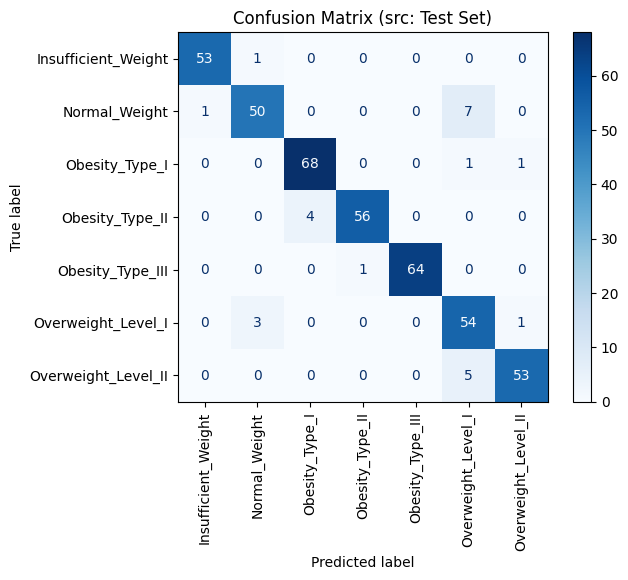

                                       Test Accuracy  Test Macro-F1  \
Best Lab 2 Classifier (Random Forest)       0.852000       0.849000   
Neural Network (MLP)                        0.940898       0.940522   

                                      Training Time Number of Parameters  
Best Lab 2 Classifier (Random Forest)         ~300s                 1000  
Neural Network (MLP)                           ~40s     4,007 parameters  


In [87]:
best_model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32, 16)).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt", map_location=DEVICE))
best_model.to(DEVICE)
best_model.eval()

all_preds = []
all_targets = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(yb.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# TODO: Evaluate on the test set.
# TODO: Report test ACCURACY and MACRO-F1
from sklearn.metrics import accuracy_score, f1_score, classification_report
test_acc = accuracy_score(all_targets, all_preds)
test_f1 = f1_score(all_targets, all_preds, average='macro')

print("Test Accuracy:", test_acc)
print("Test Macro-F1:", test_f1)
print(classification_report(all_targets, all_preds, target_names=le.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(all_targets, all_preds, display_labels=le.classes_, cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix (src: Test Set)")
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison_df = pd.DataFrame({
    "Test Accuracy": [0.8520, test_acc],
    "Test Macro-F1": [0.8490, test_f1],
    "Training Time": ["~300s", "~40s"],
    "Number of Parameters": [1000, f"{sum(p.numel() for p in best_model.parameters()):,} parameters"]},
    index = ["Best Lab 2 Classifier (Random Forest)", "Neural Network (MLP)"])

print(comparison_df)

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** 1. Normal weight and overweight level 1 are confused, as well as overweight level 1 and overweight level 2. The lab 2 classifier was also confused about normal weight and insufficient weight, and overweight level 2 and obesity type 1 in addition to the two mentioned earlier.
2. Neural Network wins. Yes. It is worth it when handling complex patterns such as in this dataset.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [1. loss.backward() calculates the gradients of the loss of every weight during back propagation. It also stores gradient for each parameter to show its contribution to the the loss in order to reduce the loss. optimizer.step() uses the calculated gradients and learning rates to update the model's weights and bias and reduce the loss.
2. Learning rate. From the experiments, the learning rates showed the most significant effect on the outputs. A too small learning rate slows down learning and a too high one leads to oscillation.
3. The largest gap occured with the largest network. Adding a dropout helped to reduce it by preventing overfitting and forcing the model to learn.
4. A plain MLP will struggle with identifying patterns from neighbouring pixels as locality will be lost in the process. To improve this we will have to reserve those relationships by using CNNs.